# 02 · Ajust objectiu de la taula de colors

La taula `LLEGENDA_RADAR` de `radar_to_nc.py` assigna una intensitat (mm/h) a cada un dels 20 colors del radar. Es va ajustar a mà. Aquí l'ajustem amb les dades.

**Per què es pot fer de manera exacta:** l'acumulat diari d'un píxel és

$$R = 0.1 \sum_{k=1}^{20} n_k \, v_k$$

on $n_k$ és el nombre d'imatges de 6 min del dia en què el píxel té el color $k$ i $v_k$ el valor assignat a aquest color. És **lineal en $v_k$**: amb els recomptes $n_k$ de cada estació i dia (`validacio/recomptes/`), ajustar la taula és un problema de mínims quadrats contra la pluja XEMA.

Provem dos models:
- **Lliure:** 20 valors independents, amb la restricció que siguin no negatius i creixents (un color més intens no pot valer menys).
- **Potència:** $v_k = a \cdot v_k^{\text{original}\,b}$, només 2 paràmetres. És l'equivalent a reajustar la relació Z-R del radar, i és molt més robust per als colors intensos, que gairebé no apareixen sobre les estacions.

**Validació:** creuada per estacions (10 grups). Cada estació s'avalua amb una taula ajustada **sense** les seves dades, per tant les mètriques mesuren com funciona en llocs no vistos. També fem una validació temporal (ajust amb març–juny, avaluació amb juliol–octubre).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import calibracio as C
C.estil()
pd.set_option('display.precision', 2); pd.set_option('display.width', 200)

In [2]:
df = C.control_qualitat(C.carregar())
df['original'] = C.radar_amb_taula(df, C.CLASSES, normalitzar=False)
df['original_normalitzat'] = C.radar_amb_taula(df, C.CLASSES, normalitzar=True)
df['lliure'], taula_lliure = C.ajust_cv(df, 'lliure')
df['potencia'], taula_pot = C.ajust_cv(df, 'potencia')
_, (a, b) = C.ajustar_potencia(C.matriu_recomptes(df[df.qc_ok]), df[df.qc_ok].obs.to_numpy())
print(f"Model potència ajustat amb totes les dades: v = {a:.2f} · v_original^{b:.2f}")

Model potència ajustat amb totes les dades: v = 2.89 · v_original^0.62


## Taules resultants

In [3]:
recompte = df[C.COLS_CLASSES].sum().to_numpy()
taules = pd.DataFrame({'original': C.CLASSES, 'lliure': taula_lliure, 'potencia': taula_pot,
                       'imatges_sobre_estacions': recompte.astype(int)},
                      index=[f"color {i+1}" for i in range(20)])
taules

,original,lliure,potencia,imatges_sobre_estacions
color 1,0.01,0.07,0.17,18116
color 2,0.03,0.07,0.33,27624
color 3,0.05,0.07,0.45,45895
color 4,0.10,0.59,0.69,41041
color 5,0.20,0.59,1.06,36096
color 6,0.40,1.75,1.64,31369
color 7,0.80,2.49,2.52,26015
color 8,1.40,3.72,3.56,20107
color 9,2.00,4.78,4.45,15463
color 10,3.00,5.93,5.72,10263


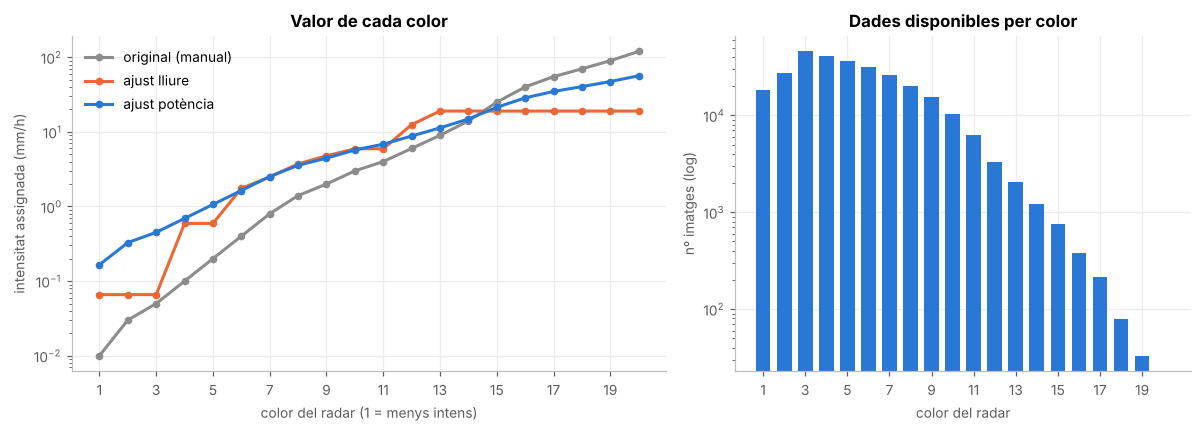

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [1.3, 1]})
ax = axs[0]
x = np.arange(20)
ax.plot(x, taules.original, color=C.COLORS['gris'], marker='o', ms=4, label='original (manual)')
ax.plot(x, taules.lliure, color=C.COLORS['taronja'], marker='o', ms=4, label='ajust lliure')
ax.plot(x, taules.potencia, color=C.COLORS['blau'], marker='o', ms=4, label='ajust potència')
ax.set(yscale='log', xlabel='color del radar (1 = menys intens)', ylabel='intensitat assignada (mm/h)',
       title='Valor de cada color', xticks=x[::2], xticklabels=x[::2] + 1)
ax.legend()
ax = axs[1]
ax.bar(x, recompte, color=C.COLORS['blau'], width=.7)
ax.set(yscale='log', xlabel='color del radar', ylabel='nº imatges (log)', title='Dades disponibles per color',
       xticks=x[::2], xticklabels=x[::2] + 1)
plt.tight_layout(); plt.show()

**Lectura:**
- Els dos ajustos pugen clarament els colors febles i mitjans (1–13): la taula original els infravalorava. Això explica bona part del biaix del notebook 01.
- Per als colors intensos (14–20) el model lliure s'estanca a ~19 mm/h. No és físic: hi ha molt poques imatges d'aquests colors sobre les estacions (cap del color 20), i en tempestes petites un error de posició de pocs km fa que el pluviòmetre no vegi el nucli. L'ajust "aprèn" aquest error de posició i rebaixa els colors intensos.
- El **model potència** no té aquest problema: amb 2 paràmetres, els colors intensos queden determinats per la forma de la corba, i mantenen un ordre físic raonable.

## Mètriques amb validació creuada per estacions

In [5]:
q = df[df.qc_ok]
cols = ['original', 'original_normalitzat', 'lliure', 'potencia']
C.taula_metriques(q, cols)

,n,ratio_total,r,MAE,RMSE,biaix_mitja,falses_alarmes_%,no_detectada_%
original,5044.0,0.46,0.51,6.87,13.21,-5.57,0.95,11.10
original_normalitzat,5044.0,0.48,0.50,6.82,13.14,-5.35,1.03,10.67
lliure,5044.0,0.93,0.62,5.97,10.84,-0.70,3.59,4.05
potencia,5044.0,0.94,0.61,5.97,10.95,-0.66,4.80,3.22


Columnes: `ratio_total` = total estimat / total observat (1 = sense biaix); `r` = correlació; MAE i RMSE en mm/dia, sobre els estació-dies amb ≥1 mm observat. `falses_alarmes_%` = % de dies secs a l'estació amb ≥1 mm estimat. `no_detectada_%` = % de dies amb ≥5 mm observats que el radar estima per sota d'1 mm.

In [6]:
# Validació temporal: ajust amb març–juny, avaluació amb juliol–octubre
tall = '2026-07-01'
tr = (df.data < tall) & df.qc_ok
te = df.data >= tall
N = C.matriu_recomptes(df)
y = df.obs.to_numpy()
v_l = C.ajustar_taula(N[tr.to_numpy()], y[tr.to_numpy()])
v_p, _ = C.ajustar_potencia(N[tr.to_numpy()], y[tr.to_numpy()])
t = df[te & df.qc_ok].copy()
Nt = C.matriu_recomptes(t)
t['lliure_temporal'] = 0.1 * Nt @ v_l
t['potencia_temporal'] = 0.1 * Nt @ v_p
C.taula_metriques(t, ['original', 'lliure_temporal', 'potencia_temporal'])

,n,ratio_total,r,MAE,RMSE,biaix_mitja,falses_alarmes_%,no_detectada_%
original,1724.0,0.54,0.53,7.61,15.69,-5.21,1.30,6.64
lliure_temporal,1724.0,0.84,0.63,7.15,13.92,-1.80,9.06,2.18
potencia_temporal,1724.0,0.84,0.64,7.05,13.82,-1.82,7.58,2.07


## Conclusions

- **Ajustar la taula redueix el biaix de ~0,5 a ~0,9** i millora la correlació (0,51 → ~0,62) i l'error (MAE 6,9 → 6,0 mm/dia) en estacions no vistes.
- En la validació temporal (mesos no vistos) la millora es manté però és més modesta: biaix 0,54 → 0,84 i MAE 7,6 → 7,0 mm/dia. La relació entre color i pluja canvia una mica segons el tipus de precipitació de cada època.
- El cost és un augment de falses alarmes: del ~1% a un 4–5% dels dies secs (fins a un 8% en la validació temporal), perquè els colors febles passen a valer més. Són quantitats petites (els colors febles sumen pocs mm), però cal tenir-ho present.
- **Recomanació: model potència** ($v = a \cdot v_{orig}^{b}$). Dona mètriques equivalents al model lliure i un comportament físic raonable als colors intensos, on no hi ha dades per ajustar-los un a un.
- Encara queda molt error: la taula no pot corregir que el biaix canviï segons el lloc (notebook 01). Això és el que fa el notebook 03.

La taula proposada es desa a `resultats/taula_colors_proposada.json`. **No s'aplica encara al pipeline.**

In [7]:
import json, os
os.makedirs('resultats', exist_ok=True)
prop = {'model': 'potencia', 'formula': 'v = a * v_original ** b', 'a': round(float(a), 4), 'b': round(float(b), 4),
        'periode_ajust': f"{df.data.min():%Y-%m-%d} / {df.data.max():%Y-%m-%d}",
        'normalitzar_per_imatges': True,
        'taula': {f"{o:g}": round(float(v), 3) for o, v in zip(C.CLASSES, taula_pot)},
        'taula_lliure_referencia': {f"{o:g}": round(float(v), 3) for o, v in zip(C.CLASSES, taula_lliure)}}
json.dump(prop, open('resultats/taula_colors_proposada.json', 'w'), indent=2, ensure_ascii=False)
print(json.dumps(prop['taula'], indent=None))

{"0.01": 0.166, "0.03": 0.328, "0.05": 0.45, "0.1": 0.692, "0.2": 1.064, "0.4": 1.637, "0.8": 2.518, "1.4": 3.564, "2": 4.447, "3": 5.72, "4": 6.839, "6": 8.797, "9": 11.315, "14": 14.887, "25": 21.338, "40": 28.569, "55": 34.815, "70": 40.439, "90": 47.268, "120": 56.512}
